In [18]:
import torch

In [19]:
n_size = 25

In [20]:
from sklearn.datasets import make_circles
n_samples = n_size  # Number of data points
noise_level = 0.05 # Add some noise for a more realistic scenario
factor_inner = 0.5 # Scale factor between inner and outer circle

circle_X, circle_y = make_circles(n_samples=n_samples, noise=noise_level, factor=factor_inner, random_state=42)
circle_X = torch.from_numpy(circle_X).float()
circle_y = torch.from_numpy(circle_y)

In [21]:
simple_X = torch.randn(size=(n_samples, 2), dtype=torch.float)
simple_y = torch.randint(0, 2, (n_samples,))

In [22]:
import torch.nn as nn
import torch.nn.functional as F

In [23]:
learning_rate = 0.01
momentum = 0.1
batch_size = 10
l2_decay = 0.001
max_steps = 100000

In [24]:
model = nn.Sequential(
    nn.Linear(2, 6),
    nn.Tanh(),
    nn.Linear(6, 2),
    nn.Tanh()
    )

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=l2_decay)



In [25]:
for step in range(max_steps):
    model.zero_grad()
    logits = model(circle_X)
    loss = F.cross_entropy(logits, circle_y)
    loss.backward()
    optimizer.step()
    if (step % 10000 == 0):
        print(f'step {step}, loss: {loss.item():.6f}')



step 0, loss: 0.723075
step 10000, loss: 0.534680
step 20000, loss: 0.208536
step 30000, loss: 0.171622
step 40000, loss: 0.161091
step 50000, loss: 0.156095
step 60000, loss: 0.153152
step 70000, loss: 0.151335
step 80000, loss: 0.150228
step 90000, loss: 0.149560


In [26]:
model.eval()

Sequential(
  (0): Linear(in_features=2, out_features=6, bias=True)
  (1): Tanh()
  (2): Linear(in_features=6, out_features=2, bias=True)
  (3): Tanh()
)

In [27]:
import matplotlib.pyplot as plt

In [28]:
import numpy as np

In [29]:
def predict(x):
 #Convert into numpy element to tensor
 x = torch.from_numpy(x).type(torch.FloatTensor)
 #Predict and return ans
 ans = model(x)
 ans = torch.argmax(F.softmax(ans, dim=-1), dim=-1)
 return ans.detach().numpy()

In [30]:
def plot_decision_boundary(X,y):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy=np.meshgrid(torch.arange(x_min, x_max, h), torch.arange(y_min, y_max, h))
    # Predict the function value for the whole gid
    Z = predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

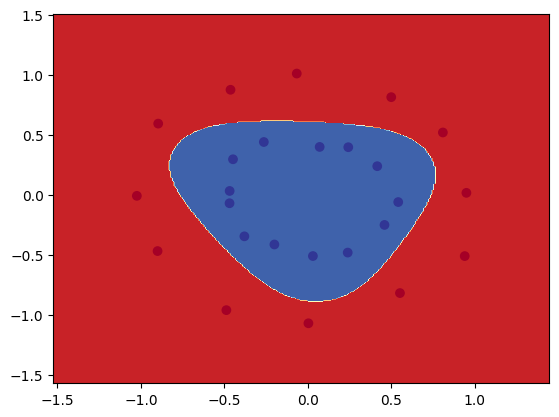

In [31]:
plot_decision_boundary(circle_X.numpy(), circle_y.numpy())
